In [1]:
import numpy as np, cv2, os, json
from pathlib import Path
from annotate_frame_jupyter import load_frame

VIDEO_PATH = 'usctimit_mri_f1_001_005_withaudio.avi'
REF_FRAME_IDX = 67
OUT_DIR = Path('annotated_3region'); OUT_DIR.mkdir(exist_ok=True)

# Paper's region grouping (Fig. 2 right panel, Shi et al. 2025)
REGION_DEF = {
    'R1': ['epiglottis', 'tongue', 'lower_teeth', 'lower_lip', 'chin', 'neck'],
    'R2': ['arytenoid', 'pharyngeal_wall', 'back', 'trachea'],
    'R3': ['hard_palate', 'velum', 'nasal_cavity', 'nose', 'upper_lip'],
}
REGION_COLORS = {'R1': 'red', 'R2': 'blue', 'R3': 'green'}
REGION_COLORS_BGR = {'R1': (0,0,255), 'R2': (255,0,0), 'R3': (0,255,0)}

frame = load_frame(VIDEO_PATH, REF_FRAME_IDX)
H, W = frame.shape
print('frame:', frame.shape, 'dtype:', frame.dtype)

frame: (68, 68) dtype: uint8


In [2]:
pip install imageio[pyav]

Note: you may need to restart the kernel to use updated packages.


In [7]:
import plotly.graph_objects as go

PLOT_CONFIG = {
    'modeBarButtonsToAdd': [
        'drawclosedpath',
        'drawopenpath',
        'eraseshape',
    ],
    'displaylogo': False,
    'edits': {'shapePosition': True},  # lets you drag/reshape after drawing
}

def make_region_annotator(frame, region='R1'):
    fig = go.FigureWidget()
    fig.add_trace(go.Heatmap(
        z=frame, colorscale='gray', showscale=False,
        zmin=frame.min(), zmax=frame.max()
    ))
    fig.update_layout(
        width=600, height=600,
        title=f'Drawing: {region} ({REGION_COLORS[region]})  |  use ✏️ to draw, 🗑️ to erase',
        dragmode='drawclosedpath',
        newshape=dict(line=dict(color=REGION_COLORS[region], width=2),
                      fillcolor=REGION_COLORS[region], opacity=0.4),
        xaxis=dict(scaleanchor='y', constrain='domain'),
        yaxis=dict(autorange='reversed'),
        margin=dict(l=10, r=10, t=40, b=10),
    )
    fig._current_region = region
    fig._config = PLOT_CONFIG          # FigureWidget picks this up on display
    return fig

def set_region(fig, region):
    fig._current_region = region
    fig.update_layout(
        title=f'Drawing: {region} ({REGION_COLORS[region]})  |  use ✏️ to draw, 🗑️ to erase',
        newshape=dict(line=dict(color=REGION_COLORS[region], width=2),
                      fillcolor=REGION_COLORS[region], opacity=0.4),
    )
    print(f'→ now drawing {region}')

# --- helpers for mistakes ---
def undo_last_shape(fig):
    shapes = list(fig.layout.shapes or [])
    if shapes:
        fig.layout.shapes = shapes[:-1]
        print(f'removed last shape, {len(shapes)-1} remaining')
    else:
        print('no shapes to undo')

def clear_region(fig, region):
    keep_color = REGION_COLORS[region]
    shapes = [s for s in (fig.layout.shapes or [])
              if (s.fillcolor or s.line.color) != keep_color]
    fig.layout.shapes = shapes
    print(f'cleared all {region} shapes')

def clear_all(fig):
    fig.layout.shapes = []
    print('cleared everything')

fig = make_region_annotator(frame, region='R1')
fig

FigureWidget({
    'data': [{'colorscale': [[0.0, 'rgb(0, 0, 0)'], [0.09090909090909091, 'rgb(16,
                             16, 16)'], [0.18181818181818182, 'rgb(38, 38, 38)'],
                             [0.2727272727272727, 'rgb(59, 59, 59)'],
                             [0.36363636363636365, 'rgb(81, 80, 80)'],
                             [0.45454545454545453, 'rgb(102, 101, 101)'],
                             [0.5454545454545454, 'rgb(124, 123, 122)'],
                             [0.6363636363636364, 'rgb(146, 146, 145)'],
                             [0.7272727272727273, 'rgb(171, 171, 170)'],
                             [0.8181818181818182, 'rgb(197, 197, 195)'],
                             [0.9090909090909091, 'rgb(224, 224, 223)'], [1.0,
                             'rgb(254, 254, 253)']],
              'showscale': False,
              'type': 'heatmap',
              'uid': 'fa0f02a9-254d-41f2-9dc6-a382658beb77',
              'z': {'bdata': ('AwoHBAcEBwQIBwkGCAcICQ

In [8]:
set_region(fig, 'R2')   # draw on the figure above

→ now drawing R2


In [9]:
set_region(fig, 'R3')           # start over

→ now drawing R3


cropped plot area: (534, 534, 3)
  R1: 536 px
  R2: 452 px
  R3: 1028 px
overlap R1&R2: 0  R1&R3: 0  R2&R3: 1


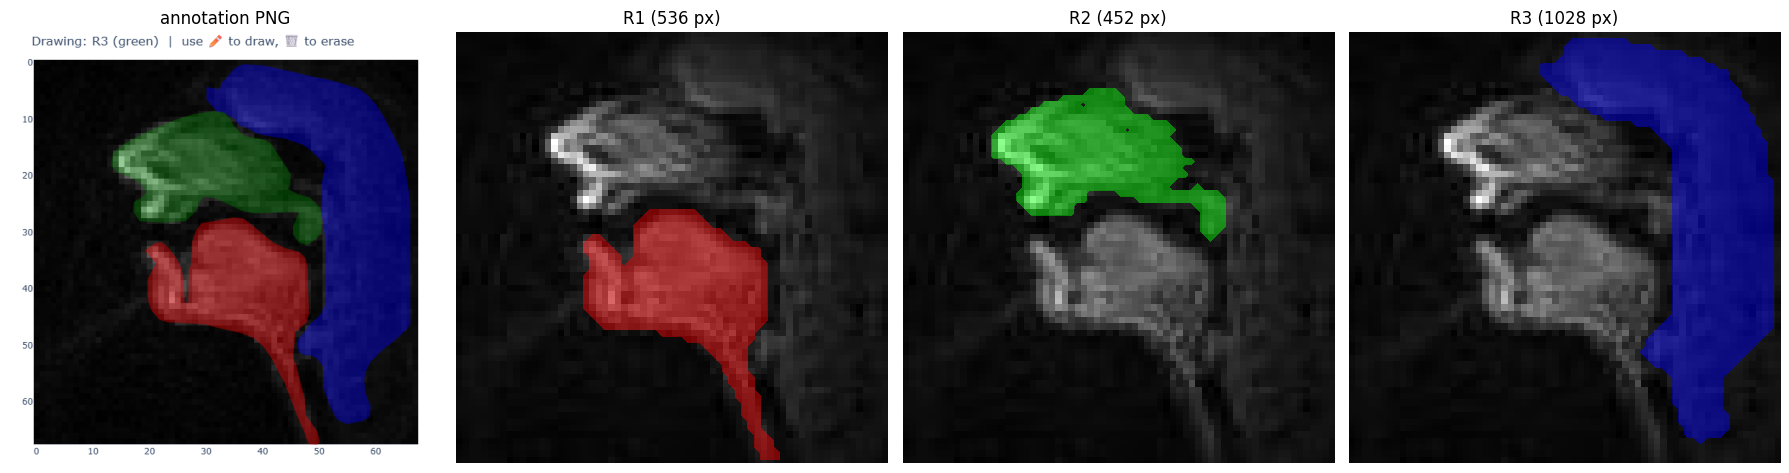

In [32]:
import cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage

DRAWN_PATH = 'newplot (17).png'
NATIVE = 68

# load the drawing
img = np.array(PILImage.open(DRAWN_PATH))[:, :, :3]

# auto-find the MRI plot area (skip plotly axis margins)
gray = img.mean(axis=2)
row_dark = (gray < 80).mean(axis=1)
col_dark = (gray < 80).mean(axis=0)
ys = np.where(row_dark > 0.3)[0]
xs = np.where(col_dark > 0.3)[0]
y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1
crop = img[y0:y1, x0:x1]
print(f'cropped plot area: {crop.shape}')

# direct RGB-channel separation
r, g, b = crop[:, :, 0].astype(int), crop[:, :, 1].astype(int), crop[:, :, 2].astype(int)
MARGIN, MIN_VAL = 20, 60
color_masks = {
    'R1': (r > g + MARGIN) & (r > b + MARGIN) & (r > MIN_VAL),   # red
    'R2': (g > r + MARGIN) & (g > b + MARGIN) & (g > MIN_VAL),   # green
    'R3': (b > r + MARGIN) & (b > g + MARGIN) & (b > MIN_VAL),   # blue
}

# downsample with INTER_AREA → threshold at 60 (the key step that worked before)
region_masks = {}
for name, cm in color_masks.items():
    small = cv2.resize(cm.astype(np.uint8) * 255, (NATIVE, NATIVE), interpolation=cv2.INTER_AREA)
    region_masks[name] = (small > 60).astype(np.uint8)
    print(f'  {name}: {region_masks[name].sum()} px')

print(f'overlap R1&R2: {(region_masks["R1"] & region_masks["R2"]).sum()}  '
      f'R1&R3: {(region_masks["R1"] & region_masks["R3"]).sum()}  '
      f'R2&R3: {(region_masks["R2"] & region_masks["R3"]).sum()}')

# save in the format the propagation cell expects
np.save('frame67_R1.npy', region_masks['R1'])
np.save('frame67_R2.npy', region_masks['R2'])
np.save('frame67_R3.npy', region_masks['R3'])

# overlay check
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(img); ax[0].set_title('annotation PNG'); ax[0].axis('off')
colors = {'R1': 'red', 'R2': 'lime', 'R3': 'blue'}
for a, name in zip(ax[1:], ['R1', 'R2', 'R3']):
    a.imshow(frames[SEED_FRAME], cmap='gray')
    a.contourf(region_masks[name], levels=[0.5, 1.5], colors=[colors[name]], alpha=0.45)
    a.set_title(f'{name} ({region_masks[name].sum()} px)'); a.axis('off')
plt.tight_layout(); plt.show()

In [35]:
# --- re-seed with the cleaned masks and re-propagate ---
import time

r1 = np.load('frame67_R1.npy').astype(bool)
r2 = np.load('frame67_R2.npy').astype(bool)
r3 = np.load('frame67_R3.npy').astype(bool)
print(f'seed areas — R1: {r1.sum()}  R2: {r2.sum()}  R3: {r3.sum()}')

predictor.reset_state(state)
for obj_id, m, name in [(1, r1, 'R1'), (2, r2, 'R2'), (3, r3, 'R3')]:
    predictor.add_new_mask(inference_state=state, frame_idx=SEED_FRAME, obj_id=obj_id, mask=m)
    print(f'seeded {name} (obj_id={obj_id}) area={m.sum()} px')

segs = {}
t0 = time.time()
for fidx, oids, logits in predictor.propagate_in_video(state):
    segs[fidx] = {oid: (logits[i, 0] > 0).cpu().numpy() for i, oid in enumerate(oids)}
for fidx, oids, logits in predictor.propagate_in_video(state, reverse=True):
    if fidx not in segs:
        segs[fidx] = {oid: (logits[i, 0] > 0).cpu().numpy() for i, oid in enumerate(oids)}
print(f'propagated {len(segs)} frames in {time.time() - t0:.1f}s')

# save per-frame masks
for fidx, d in segs.items():
    np.savez_compressed(
        MASKS_OUT / f'f{fidx:04d}.npz',
        R1=d.get(1, np.zeros_like(r1)).astype(np.uint8),
        R2=d.get(2, np.zeros_like(r1)).astype(np.uint8),
        R3=d.get(3, np.zeros_like(r1)).astype(np.uint8),
    )

# sanity
for f in [0, SEED_FRAME, SEED_FRAME + 30, max(segs)]:
    if f in segs:
        d = segs[f]
        print(f'frame {f:3d}  R1: {d[1].sum():4d}  R2: {d[2].sum():4d}  R3: {d[3].sum():4d}')

seed areas — R1: 536  R2: 452  R3: 1028
seeded R1 (obj_id=1) area=536 px
seeded R2 (obj_id=2) area=452 px
seeded R3 (obj_id=3) area=1028 px


propagate in video: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:24<00:00,  2.82it/s]

propagated 442 frames in 158.0s
frame   0  R1:  618  R2:  396  R3:  940
frame  67  R1:  536  R2:  452  R3: 1028
frame  97  R1:  547  R2:  453  R3:  953
frame 441  R1:  546  R2:  458  R3:  931


In [36]:
# --- HQ tracked video (8× upscaled with contours + frame numbers) ---
import cv2, numpy as np

SCALE   = 8
H2, W2  = H * SCALE, W * SCALE
FPS     = 23.18
OUT_VID = 'masks_3region/sam2_3region_track_hq.mp4'

COLORS_BGR = {1: (60, 60, 255),    # R1 red
              2: (60, 200, 60),    # R2 green
              3: (255, 100, 60)}   # R3 blue

def overlay_hq(gray, masks, alpha=0.40):
    big = cv2.resize(gray, (W2, H2), interpolation=cv2.INTER_CUBIC)
    big = cv2.cvtColor(big, cv2.COLOR_GRAY2BGR).astype(np.float32)
    out = big.copy()
    for oid, m in masks.items():
        m = m.astype(np.uint8)
        if m.shape != gray.shape:
            m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
        m_up = cv2.resize(m * 255, (W2, H2), interpolation=cv2.INTER_NEAREST)
        col = np.array(COLORS_BGR[oid], dtype=np.float32)
        sel = m_up > 0
        out[sel] = (1 - alpha) * out[sel] + alpha * col
    out = np.clip(out, 0, 255).astype(np.uint8)
    for oid, m in masks.items():
        m = m.astype(np.uint8)
        if m.shape != gray.shape:
            m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
        m_up = cv2.resize(m * 255, (W2, H2), interpolation=cv2.INTER_NEAREST)
        cnts, _ = cv2.findContours(m_up, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, cnts, -1, COLORS_BGR[oid], 2, lineType=cv2.LINE_AA)
    return out

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
vw = cv2.VideoWriter(OUT_VID, fourcc, FPS, (W2, H2))
for i, g in enumerate(frames):
    if i in segs:
        img = overlay_hq(g, segs[i])
    else:
        img = cv2.cvtColor(cv2.resize(g, (W2, H2), interpolation=cv2.INTER_CUBIC), cv2.COLOR_GRAY2BGR)
    cv2.putText(img, f'frame {i}', (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (255, 255, 255), 2, cv2.LINE_AA)
    if i == SEED_FRAME:
        cv2.putText(img, 'SEED', (W2 - 90, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (0, 255, 255), 2, cv2.LINE_AA)
    vw.write(img)
vw.release()
print(f'wrote {OUT_VID}  →  {W2}x{H2} @ {FPS:.2f} fps, {len(frames)} frames')

wrote masks_3region/sam2_3region_track_hq.mp4  →  544x544 @ 23.18 fps, 442 frames


cropped plot area: (535, 534, 3)
  R1: 559 px
  R2: 1053 px
  R3: 479 px

✓ saved → annotated_3region/regions_frame_67.npz


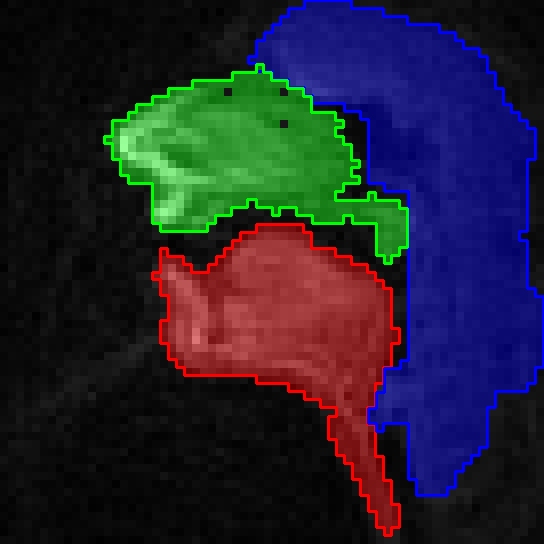

In [21]:

import cv2, numpy as np
from pathlib import Path
from PIL import Image as PILImage

DRAWN_PATH = 'newplot (16).png'
H, W = frame.shape

# load the drawing
img = np.array(PILImage.open(DRAWN_PATH))[:,:,:3]

# auto-find the MRI plot area (skip plotly axis margins)
gray = img.mean(axis=2)
row_dark = (gray < 80).mean(axis=1)
col_dark = (gray < 80).mean(axis=0)
ys = np.where(row_dark > 0.3)[0]
xs = np.where(col_dark > 0.3)[0]
y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1
crop = img[y0:y1, x0:x1]
print(f'cropped plot area: {crop.shape}')

# direct RGB-channel separation (no HSV, no winner-take-all, no morphology)
r, g, b = crop[:,:,0].astype(int), crop[:,:,1].astype(int), crop[:,:,2].astype(int)
MARGIN = 20      # how much one channel must dominate the other two
MIN_VAL = 60     # minimum intensity to count as "drawn" (skips dark MRI background)

color_masks = {
    'R1': (r > g + MARGIN) & (r > b + MARGIN) & (r > MIN_VAL),   # red
    'R2': (b > r + MARGIN) & (b > g + MARGIN) & (b > MIN_VAL),   # blue
    'R3': (g > r + MARGIN) & (g > b + MARGIN) & (g > MIN_VAL),   # green
}

# downsample each to native MRI res (68×68)
region_masks = {}
for name, cm in color_masks.items():
    small = cv2.resize(cm.astype(np.uint8) * 255, (W, H), interpolation=cv2.INTER_AREA)
    region_masks[name] = ((small > 60).astype(np.uint8)) * 255
    print(f'  {name}: {int((region_masks[name] > 0).sum())} px')

# save
np.savez_compressed(OUT_DIR / f'regions_frame_{REF_FRAME_IDX}.npz', **region_masks)
print(f'\n✓ saved → {OUT_DIR}/regions_frame_{REF_FRAME_IDX}.npz')

# overlay
REGION_COLORS_BGR = {'R1': (0,0,255), 'R2': (255,0,0), 'R3': (0,255,0)}
base = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
big = cv2.resize(base, (W*8, H*8), interpolation=cv2.INTER_NEAREST)
fill = big.copy()
for r_, m in region_masks.items():
    mu = cv2.resize(m, (W*8, H*8), interpolation=cv2.INTER_NEAREST)
    fill[mu > 0] = REGION_COLORS_BGR[r_]
big = cv2.addWeighted(fill, 0.4, big, 0.6, 0)
for r_, m in region_masks.items():
    mu = cv2.resize(m, (W*8, H*8), interpolation=cv2.INTER_NEAREST)
    cnts, _ = cv2.findContours(mu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(big, cnts, -1, REGION_COLORS_BGR[r_], 2)

cv2.imwrite(str(OUT_DIR / f'ref_frame_{REF_FRAME_IDX}_clean.png'), big)
PILImage.open(OUT_DIR / f'ref_frame_{REF_FRAME_IDX}_clean.png')